In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import sys

sys.path.append(str(Path('..').resolve()))

data_path = Path("../data/stock_a.csv")
df = pd.read_csv(data_path, parse_dates=['timestamp'])

In [2]:
df

,timestamp,X1,X2,X3,price,bid,ask,returns
0,2020-01-01,NaN,-9.554574,-0.177239,100.00,99.95,100.05,-0.010538
1,2020-01-02,-3.193259,-4.991605,0.820378,98.95,98.90,99.00,-0.003323
2,2020-01-03,-5.326122,-3.871662,2.657185,98.62,98.57,98.67,-0.004748
3,2020-01-06,2.627210,1.327929,4.689063,98.15,98.10,98.20,0.000031
4,2020-01-07,11.737632,3.630729,2.777931,98.15,98.10,98.20,0.012481
...,...,...,...,...,...,...,...,...
9995,2058-04-24,5.179375,5.020967,-2.048770,59.41,59.38,59.44,0.004781
9996,2058-04-25,11.775321,2.769774,-3.322056,59.69,59.66,59.72,0.012283
9997,2058-04-26,3.078223,2.581138,0.923115,60.42,60.39,60.45,0.005578
9998,2058-04-29,17.631063,2.180761,-6.280703,60.76,60.73,60.79,0.016241


In [3]:
# from ydata_profiling import ProfileReport
# profile = ProfileReport(df, title="Data Profile")
# profile.to_file("report.html")

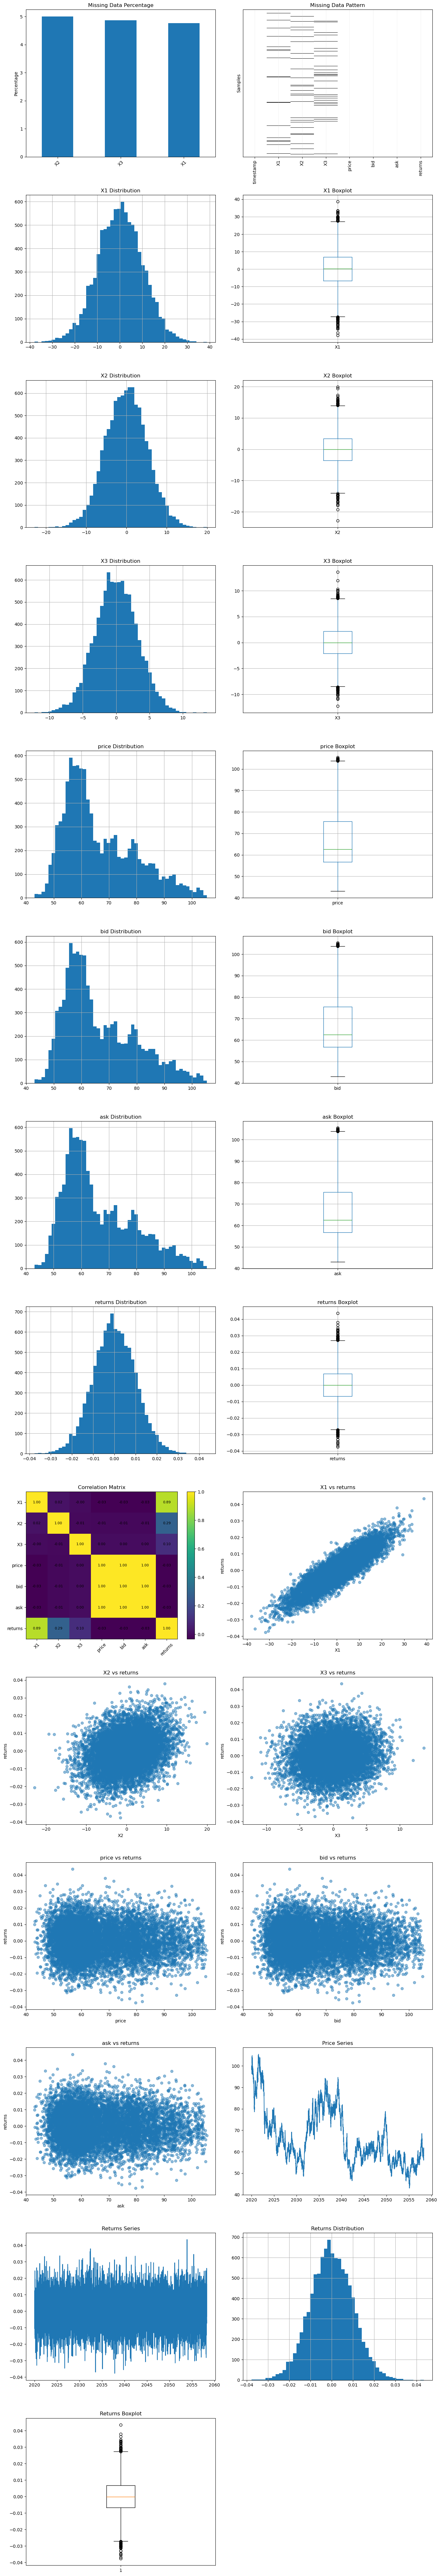

EDA completed: Charts displayed inline.


In [4]:
from models.visualizing import EDAVisualizer, ModelVisualizer

visualizer = EDAVisualizer(df,
                           target='returns',
                           timestamp_col='timestamp',
                           price_col='price')
visualizer.run_all()

In [5]:
from models.preparing import Dataset

data_prep = Dataset(
    df,
    target='returns',
    features = None,
    timestamp_col = 'timestamp',
    )

data_prep.prepare_dataset(
    test_size = 0.2,
    shuffle = False,
    scale_numeric = True,
    use_knn_for_numeric=True,
    )

############################################# DECODE CAT FEATURES ##########################################################

# ohe = data_prep._preprocessor.named_transformers_['cat']
# df_copy = datasets['X_train'].copy()

# for col in ohe.feature_names_in_:
#     cat_col = [c for c in df_copy.columns if col in c]
#     df_copy[col] = ohe.named_steps['ohe'].inverse_transform(datasets['X_train'][cat_col]).flatten().tolist()

## Using YAML Experiment Configs with `ModelTrainer`

The `ModelTrainer` now supports three modes:

### Mode 1 — No Config (default)
Full Optuna search over all model types.

### Mode 2 — Fixed Params (`params` key in YAML)
Skips Optuna entirely. Trains exactly with the params listed in the YAML file.
```yaml
model: xgb
is_classification: false
params:
  n_estimators: 300
  learning_rate: 0.05
```

### Mode 3 — Optuna Hints (`optuna_hints` key in YAML)
Optuna still searches, but seeds its first trial with the hint values.
```yaml
model: xgb
is_classification: false
optuna_hints:
  n_estimators: 200
  learning_rate: 0.05
```

In [6]:
import os
from models.modeling import ModelTrainer

# Path to experiments directory (relative to repo root)
EXPERIMENTS_DIR = os.path.join(
    os.path.dirname(os.path.abspath(os.getcwd())), 'experiments'
)

# ─── Mode 1: No config — full Optuna search (all model types) ───────────────
print('=== Mode 1: No YAML config (full Optuna search) ===')
trainer_no_cfg = ModelTrainer(
    data_prep,
    is_classification=False,
    n_trials=50,
)

# ─── Mode 2: Fixed params from YAML — skips Optuna ──────────────────────────
cfg_fixed = os.path.join(EXPERIMENTS_DIR, 'exp_003_xgb_regression.yaml')
print('\n=== Mode 2: Fixed-params YAML (no Optuna) ===')
trainer_fixed = ModelTrainer(
    data_prep,
    config_path=cfg_fixed,
)

# ─── Mode 3: Optuna with hints from YAML ────────────────────────────────────
cfg_hints = os.path.join(EXPERIMENTS_DIR, 'exp_005_xgb_optuna_hints.yaml')
print('\n=== Mode 3: Optuna-hints YAML ===')
trainer_hints = ModelTrainer(
    data_prep,
    n_trials=50,
    config_path=cfg_hints,
)

# ─── View accumulated experiment results ────────────────────────────────────
import pandas as pd
results_csv = os.path.join(EXPERIMENTS_DIR, 'results.csv')
print('\n=== Experiment Results ===')
print(pd.read_csv(results_csv).to_string())


[I 2026-03-27 13:05:28,837] A new study created in memory with name: no-name-22732ec6-c8e0-49b9-9cfb-86b579dc29a4
[I 2026-03-27 13:05:28,858] Trial 0 finished with value: 0.00420524674601618 and parameters: {'model_type': 'linear', 'fit_intercept': False}. Best is trial 0 with value: 0.00420524674601618.


=== Mode 1: No YAML config (full Optuna search) ===
Starting model optimization with 50 trials...


[I 2026-03-27 13:05:30,911] Trial 1 finished with value: 0.004995757138913953 and parameters: {'model_type': 'rf', 'n_estimators': 65, 'max_depth': 3, 'min_samples_split': 19, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.00420524674601618.
[I 2026-03-27 13:05:30,917] Trial 2 finished with value: 0.00420524674601618 and parameters: {'model_type': 'linear', 'fit_intercept': False}. Best is trial 0 with value: 0.00420524674601618.
[I 2026-03-27 13:05:48,852] Trial 3 finished with value: 0.004317657741462334 and parameters: {'model_type': 'rf', 'n_estimators': 252, 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.00420524674601618.
[I 2026-03-27 13:05:48,866] Trial 4 finished with value: 0.004205441506818193 and parameters: {'model_type': 'linear', 'fit_intercept': True}. Best is trial 0 with value: 0.00420524674601618.
[I 2026-03-27 13:05:49,985] Trial 5 pruned. 
[I 2026-03-27 13:05:49,992] Trial 6 finished with value: 0.00420544150681

Optimization complete
  Best model : LinearRegression
  Best params: {'fit_intercept': False}
Top 20 Coefficients (by abs value):
  num__bid: -0.022993
  num__ask: 0.022975
  num__X1: 0.008578
  num__X2: 0.002653
  num__X3: 0.001087
  num__price: 0.000002
Mean Squared Error (Train): 0.000018
RMSE             (Train): 0.004205
R^2 Score        (Train): 0.822804
Mean Squared Error (Test): 0.000018
RMSE             (Test):  0.004199
R^2 Score        (Test):  0.825322

=== Mode 2: Fixed-params YAML (no Optuna) ===
[YAML] Fixed-params mode — model: xgb, params: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'objective': 'reg:squarederror'}


[I 2026-03-27 13:06:08,216] A new study created in memory with name: no-name-2537e11c-8a90-46f3-9c01-0fe190b4a0e5


Feature Importances (Top 20):
  num__X1: 0.890807
  num__X2: 0.077896
  num__X3: 0.016477
  num__price: 0.005832
  num__bid: 0.005214
  num__ask: 0.003774
Mean Squared Error (Train): 0.000016
RMSE             (Train): 0.004014
R^2 Score        (Train): 0.838500
Mean Squared Error (Test): 0.000019
RMSE             (Test):  0.004323
R^2 Score        (Test):  0.814803

=== Mode 3: Optuna-hints YAML ===
Starting model optimization with 50 trials...


[I 2026-03-27 13:06:09,860] Trial 0 finished with value: 0.004291632490926277 and parameters: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'colsample_bytree': 0.8, 'reg_alpha': 0.01, 'reg_lambda': 1.0}. Best is trial 0 with value: 0.004291632490926277.
[I 2026-03-27 13:06:10,361] Trial 1 finished with value: 0.00875734125103891 and parameters: {'n_estimators': 119, 'learning_rate': 0.0018335668718025089, 'max_depth': 3, 'colsample_bytree': 0.9507436163559544, 'reg_alpha': 2.5636093854151125e-07, 'reg_lambda': 0.010124052698290928}. Best is trial 0 with value: 0.004291632490926277.
[I 2026-03-27 13:06:11,610] Trial 2 finished with value: 0.006689032144504603 and parameters: {'n_estimators': 309, 'learning_rate': 0.003147100623752525, 'max_depth': 3, 'colsample_bytree': 0.8000021958941219, 'reg_alpha': 0.09407391507251593, 'reg_lambda': 6.2398953475071535}. Best is trial 0 with value: 0.004291632490926277.
[I 2026-03-27 13:06:15,590] Trial 3 finished with value: 0.0083906

Optimization complete
  Best model : XGBRegressor
  Best params: {'n_estimators': 499, 'learning_rate': 0.025016992090564804, 'max_depth': 3, 'colsample_bytree': 0.8193169442156369, 'reg_alpha': 4.04289106471982e-05, 'reg_lambda': 1.00433233151702e-05}
Feature Importances (Top 20):
  num__X1: 0.853399
  num__X2: 0.101212
  num__X3: 0.025627
  num__ask: 0.007424
  num__bid: 0.006447
  num__price: 0.005891
Mean Squared Error (Train): 0.000016
RMSE             (Train): 0.004060
R^2 Score        (Train): 0.834776
Mean Squared Error (Test): 0.000018
RMSE             (Test):  0.004269
R^2 Score        (Test):  0.819425

=== Experiment Results ===
      experiment_id                    config             model  accuracy  auc      rmse        r2
0   20260324_125049                 no_config  LinearRegression       NaN  NaN  0.004199  0.825322
1   20260324_125049    exp_003_xgb_regression      XGBRegressor       NaN  NaN  0.004323  0.814803
2   20260324_125111  exp_005_xgb_optuna_hints      XGB

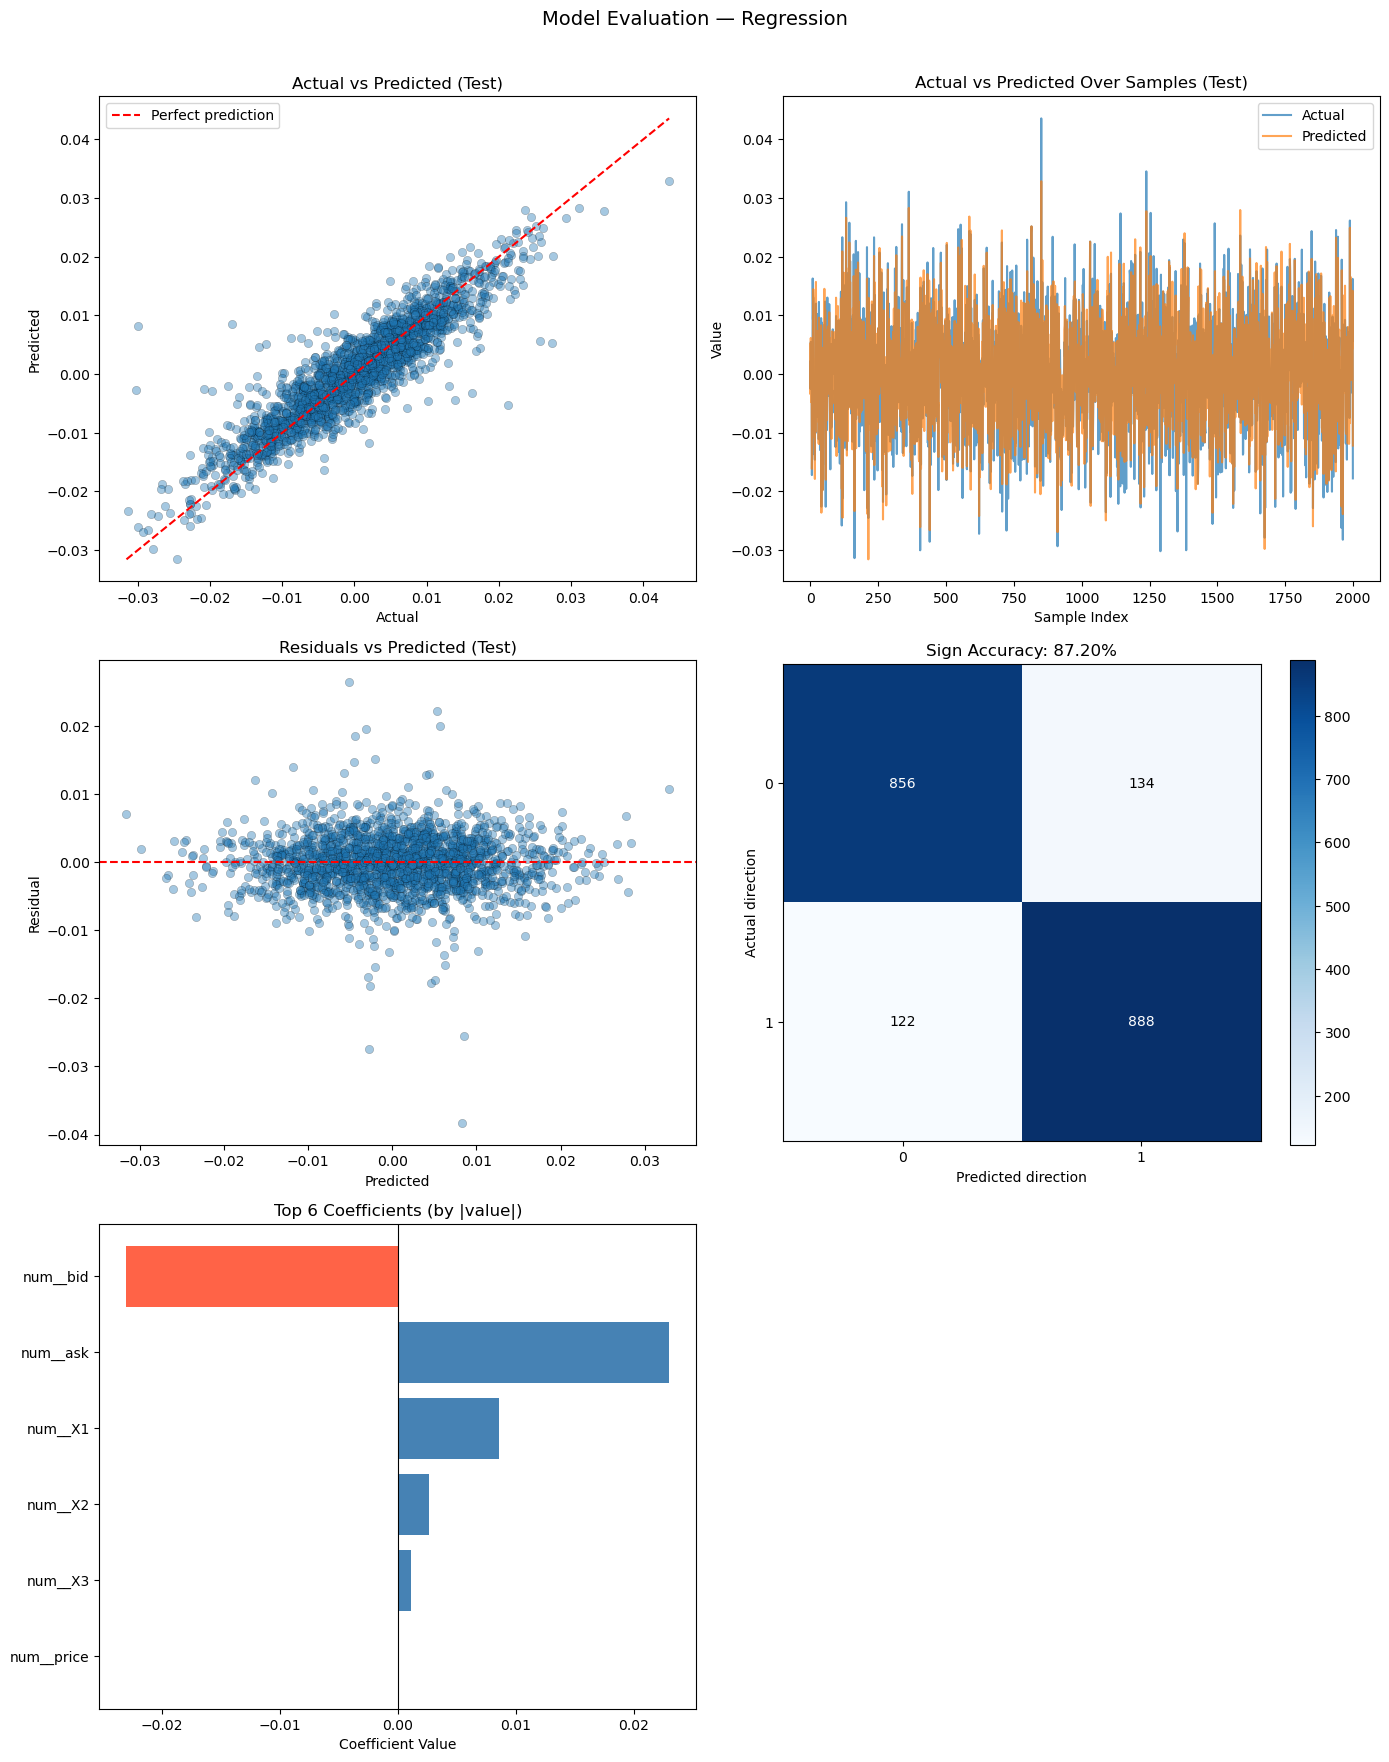

In [7]:
ModelVisualizer(trainer_no_cfg).run_all()